In [79]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

In [80]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
df = pd.read_csv(url)

In [81]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [83]:
# Encoding the targets

df['species'] = df['species'].replace(
    {'setosa': 0, 'versicolor': 1, 'virginica': 2}
)

/tmp/ipykernel_1046/2049195208.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['species'] = df['species'].replace(


In [84]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [85]:
# Defining features and target

features = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
target = df['species']

In [86]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [87]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [88]:
# Defining the tensors for nn
X_train_tensor = torch.tensor(x_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)
Y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
Y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [89]:
import torch.nn as nn

# Model class

class IrisClassifier(nn.Module):

  def __init__(self, in_features = 4, hidden_size = 10, out_features = 3):
    super().__init__()
    self.fully_connected1 = nn.Linear(in_features, hidden_size)
    self.fully_connected2 = nn.Linear(hidden_size, out_features)
    self.relu = nn.ReLU()

  def forward(self, features):
    out = self.fully_connected1(features)
    out = self.relu(out)
    out = self.fully_connected2(out)
    return out

In [90]:
# Defining Model, loss, optimizer (comparison)

LEARNING_RATE = 0.1

model_adam = IrisClassifier(X_train_tensor.shape[1])
model_SGD = IrisClassifier(X_train_tensor.shape[1])
model_SGD_momentum = IrisClassifier(X_train_tensor.shape[1])

loss = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=LEARNING_RATE)
optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr=LEARNING_RATE)
optimizer_SGD_momentum = torch.optim.SGD(model_SGD_momentum.parameters(), lr=LEARNING_RATE, momentum=0.9)

In [91]:
# Training pipeline

EPOCHES = 10000
ADAM_LOSSES = []

for i in range(EPOCHES):

    # Calculating predicted values
    y_pred = model_adam(X_train_tensor)

    # Calculating CrossEntropyLoss
    loss_value = loss(y_pred, Y_train_tensor)

    # Making gradients zero
    optimizer_adam.zero_grad()

    # backpropagation
    loss_value.backward()

    # Updating Model Parameters
    optimizer_adam.step()


    # Printing loss after 100 epoch
    if i % 1000 == 0:
        print(f'Epoch: {i} Loss: {loss_value}')

    ADAM_LOSSES.append(loss_value)




Epoch: 0 Loss: 1.4674935340881348
Epoch: 1000 Loss: 0.04681665077805519
Epoch: 2000 Loss: 0.055849771946668625
Epoch: 3000 Loss: 0.046588197350502014
Epoch: 4000 Loss: 0.046601008623838425
Epoch: 5000 Loss: 0.046757109463214874
Epoch: 6000 Loss: 0.04658760502934456
Epoch: 7000 Loss: 0.04659062251448631
Epoch: 8000 Loss: 0.04658353701233864
Epoch: 9000 Loss: 0.04660208895802498


In [92]:

SGD_LOSSES = []

for i in range(EPOCHES):

    # Calculating predicted values
    y_pred = model_SGD(X_train_tensor)

    # Calculating CrossEntropyLoss
    loss_value = loss(y_pred, Y_train_tensor)

    # Making gradients zero
    optimizer_SGD.zero_grad()


    # backpropagation
    loss_value.backward()

    # Updating Model Parameter
    optimizer_SGD.step()


    # Printing loss after 100 epoch
    if i % 1000 == 0:
        print(f'Epoch: {i} Loss: {loss_value}')

    SGD_LOSSES.append(loss_value)

Epoch: 0 Loss: 1.2500020265579224
Epoch: 1000 Loss: 0.07708900421857834
Epoch: 2000 Loss: 0.06518088281154633
Epoch: 3000 Loss: 0.06545478850603104
Epoch: 4000 Loss: 0.06274864077568054
Epoch: 5000 Loss: 0.06089266762137413
Epoch: 6000 Loss: 0.05945412069559097
Epoch: 7000 Loss: 0.05831315368413925
Epoch: 8000 Loss: 0.05737525224685669
Epoch: 9000 Loss: 0.056577879935503006


In [93]:
SGD_MOMENTUM = []

for i in range(EPOCHES):

    # Calculating predicted values
    y_pred = model_SGD_momentum(X_train_tensor)

    # Calculating CrossEntropyLoss
    loss_value = loss(y_pred, Y_train_tensor)

    # Making gradients zero
    optimizer_SGD_momentum.zero_grad()

    # backpropagation
    loss_value.backward()

    # Updating Model Parameters
    optimizer_SGD_momentum.step()

    # Printing loss after 100 epoch
    if i % 1000 == 0:
        print(f'Epoch: {i} Loss: {loss_value}')

    SGD_MOMENTUM.append(loss_value)

Epoch: 0 Loss: 1.1113163232803345
Epoch: 1000 Loss: 0.04913332313299179
Epoch: 2000 Loss: 0.04700221121311188
Epoch: 3000 Loss: 0.05035623162984848
Epoch: 4000 Loss: 0.04662071540951729
Epoch: 5000 Loss: 0.04659631475806236
Epoch: 6000 Loss: 0.04658888652920723
Epoch: 7000 Loss: 0.046933647245168686
Epoch: 8000 Loss: 0.04710659012198448
Epoch: 9000 Loss: 0.04660819098353386


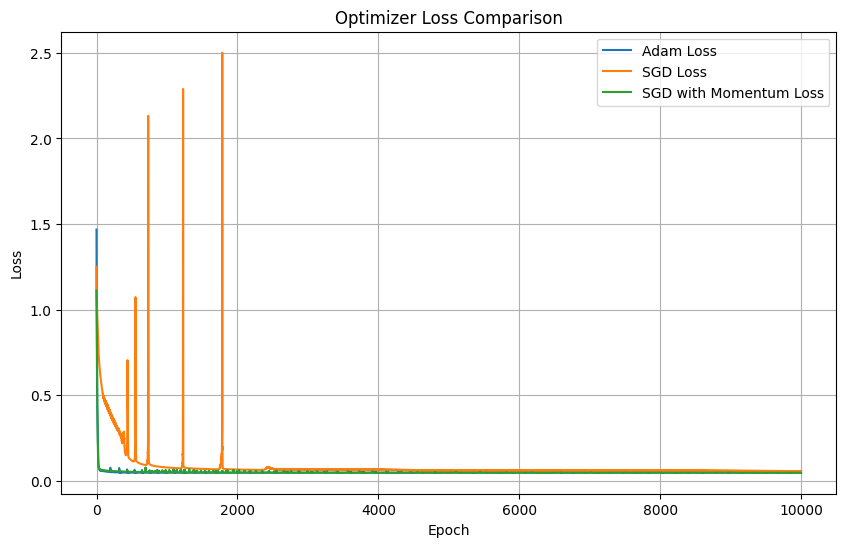

In [95]:
plt.figure(figsize=(10, 6))
plt.plot([loss.detach().numpy() for loss in ADAM_LOSSES], label='Adam Loss')
plt.plot([loss.detach().numpy() for loss in SGD_LOSSES], label='SGD Loss')
plt.plot([loss.detach().numpy() for loss in SGD_MOMENTUM], label='SGD with Momentum Loss')
plt.title('Optimizer Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Model Accuracy on Test Set

In [96]:
# Calculate accuracy for model_adam
model_adam.eval() # Set model to evaluation mode
with torch.no_grad():
    y_pred_adam = model_adam(X_test_tensor)
    _, predicted_adam = torch.max(y_pred_adam.data, 1)
    accuracy_adam = (predicted_adam == Y_test_tensor).sum().item() / Y_test_tensor.size(0)
print(f'Accuracy of Adam model on the test set: {accuracy_adam:.4f}')

# Calculate accuracy for model_SGD
model_SGD.eval() # Set model to evaluation mode
with torch.no_grad():
    y_pred_sgd = model_SGD(X_test_tensor)
    _, predicted_sgd = torch.max(y_pred_sgd.data, 1)
    accuracy_sgd = (predicted_sgd == Y_test_tensor).sum().item() / Y_test_tensor.size(0)
print(f'Accuracy of SGD model on the test set: {accuracy_sgd:.4f}')

# Calculate accuracy for model_SGD_momentum
model_SGD_momentum.eval() # Set model to evaluation mode
with torch.no_grad():
    y_pred_sgd_momentum = model_SGD_momentum(X_test_tensor)
    _, predicted_sgd_momentum = torch.max(y_pred_sgd_momentum.data, 1)
    accuracy_sgd_momentum = (predicted_sgd_momentum == Y_test_tensor).sum().item() / Y_test_tensor.size(0)
print(f'Accuracy of SGD with Momentum model on the test set: {accuracy_sgd_momentum:.4f}')

Accuracy of Adam model on the test set: 1.0000
Accuracy of SGD model on the test set: 1.0000
Accuracy of SGD with Momentum model on the test set: 1.0000


In [100]:
from torchsummary import summary

summary(model_adam, input_size=(1, X_train_tensor.shape[1]))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 10]              50
              ReLU-2                [-1, 1, 10]               0
            Linear-3                 [-1, 1, 3]              33
Total params: 83
Trainable params: 83
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
